# Understanding Vector Embeddings

This notebook explains how text is converted into numerical representations (vectors) that machines can understand and process.

## Journey from Text to Semantic Embeddings

We'll explore:
1. **Tokenization & Chunking** - Breaking text into pieces
2. **Basic Encodings** - Binary, One-Hot, Multi-Hot (Bag of Words)
3. **Why Basic Encodings Fail** - The semantic gap
4. **Dense Embeddings** - Continuous vectors that capture meaning
5. **Practical Examples** - Using Sentence Transformers and Mistral
6. **Visualization** - Heatmaps showing semantic relationships

---

In [8]:
# Install required packages
! pip install  mistralai python-dotenv matplotlib seaborn numpy scikit-learn pandas -q


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# ! pip uninstall numpy -y
# ! pip install numpy==1.26.4
# ! pip install transformers==4.44.2
# ! pip install sentence-transformers==3.3.1


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/11/57/baae43d14fe163fa0e4c47f307b6b2511ab8d7d30177c491960504252053/numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl.metadata
  Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl (20.6 MB)

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from mistralai.client import Mistral
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Setup plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

/Users/raamraam/Downloads/GenAIEngineering-Cohort5/Week4/Day_1_and_2/week4_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All libraries imported successfully!


---

## Part 4: Dense Embeddings with Sentence Transformers

Now let's see real dense embeddings in action using the open-source **Sentence Transformers** library.

We'll use a small model that produces **32-dimensional embeddings** for visualization purposes.

In [17]:
print("=" * 80)
print("LOADING SENTENCE TRANSFORMER MODEL")
print("=" * 80)

# Load a small model for demonstration
# Note: For production, use larger models like 'all-MiniLM-L6-v2' (384 dims)
model_name = 'sentence-transformers/all-MiniLM-L6-v2'
print(f"\nLoading model: {model_name}")
print("This may take a moment on first run...\n")

st_model = SentenceTransformer(model_name)

print(f"✓ Model loaded!")
print(f"Embedding dimension: {st_model.get_sentence_embedding_dimension()}")

LOADING SENTENCE TRANSFORMER MODEL

Loading model: sentence-transformers/all-MiniLM-L6-v2
This may take a moment on first run...

✓ Model loaded!
Embedding dimension: 384


In [18]:
print("\n" + "=" * 80)
print("GENERATING EMBEDDINGS FOR 5 DIFFERENT SUBJECTS")
print("=" * 80)

# 5 sentences from different domains
sentences = [
    "The cat sat on the mat and purred contentedly.",  # Animals/Pets
    "Machine learning algorithms process vast amounts of data.",  # Technology/AI
    "The doctor examined the patient's symptoms carefully.",  # Medical/Healthcare
    "the blood pressure is normal.",
    "The stock market experienced significant volatility today.",  # Finance/Economics
    "The chef prepared a delicious Italian pasta dish.",  # Food/Cooking
    "The indian cuisine is spicy and full of flavor."  # Food/Cooking

]

topics = ["Animals", "Technology", "Medical", "Medical", "Finance", "Food", "Food"]

print("\nSentences to embed:\n")
for i, (topic, sentence) in enumerate(zip(topics, sentences), 1):
    print(f"{i}. [{topic}] {sentence}")

# Generate embeddings
print("\nGenerating embeddings...")
embeddings = st_model.encode(sentences)

print(f"\n✓ Generated embeddings!")
print(f"Shape: {embeddings.shape}")
print(f"  • {embeddings.shape[0]} sentences")
print(f"  • {embeddings.shape[1]} dimensions per embedding")


GENERATING EMBEDDINGS FOR 5 DIFFERENT SUBJECTS

Sentences to embed:

1. [Animals] The cat sat on the mat and purred contentedly.
2. [Technology] Machine learning algorithms process vast amounts of data.
3. [Medical] The doctor examined the patient's symptoms carefully.
4. [Medical] the blood pressure is normal.
5. [Finance] The stock market experienced significant volatility today.
6. [Food] The chef prepared a delicious Italian pasta dish.
7. [Food] The indian cuisine is spicy and full of flavor.

Generating embeddings...

✓ Generated embeddings!
Shape: (7, 384)
  • 7 sentences
  • 384 dimensions per embedding


In [19]:
# Reduce to 32 dimensions for visualization
from sklearn.decomposition import PCA

print("\n" + "=" * 80)
print("REDUCING TO 32 DIMENSIONS FOR VISUALIZATION")
print("=" * 80)

# Reduce dimensions for visualization
pca = PCA(n_components=5)
embeddings_32d = pca.fit_transform(embeddings)

print(f"\nReduced from {embeddings.shape[1]}D to 32D")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Show first few dimensions for one embedding
print(f"\nExample: First 10 dimensions of '{topics[0]}' embedding:")
print(embeddings_32d[0][:10])
print("\nℹ️  Each number captures semantic features (continuous, not binary!)")


REDUCING TO 32 DIMENSIONS FOR VISUALIZATION

Reduced from 384D to 32D
Variance explained: 88.10%

Example: First 10 dimensions of 'Animals' embedding:
[-0.02403913 -0.68260777 -0.4124689   0.06208012 -0.44898415]

ℹ️  Each number captures semantic features (continuous, not binary!)


### 4.1 Visualizing Embeddings with Heatmap

Each row is a sentence, each column is a dimension. The **color intensity** shows the magnitude of the number in that dimension - indicating how much that semantic feature applies.

HEATMAP: Embedding Vectors (32 Dimensions)


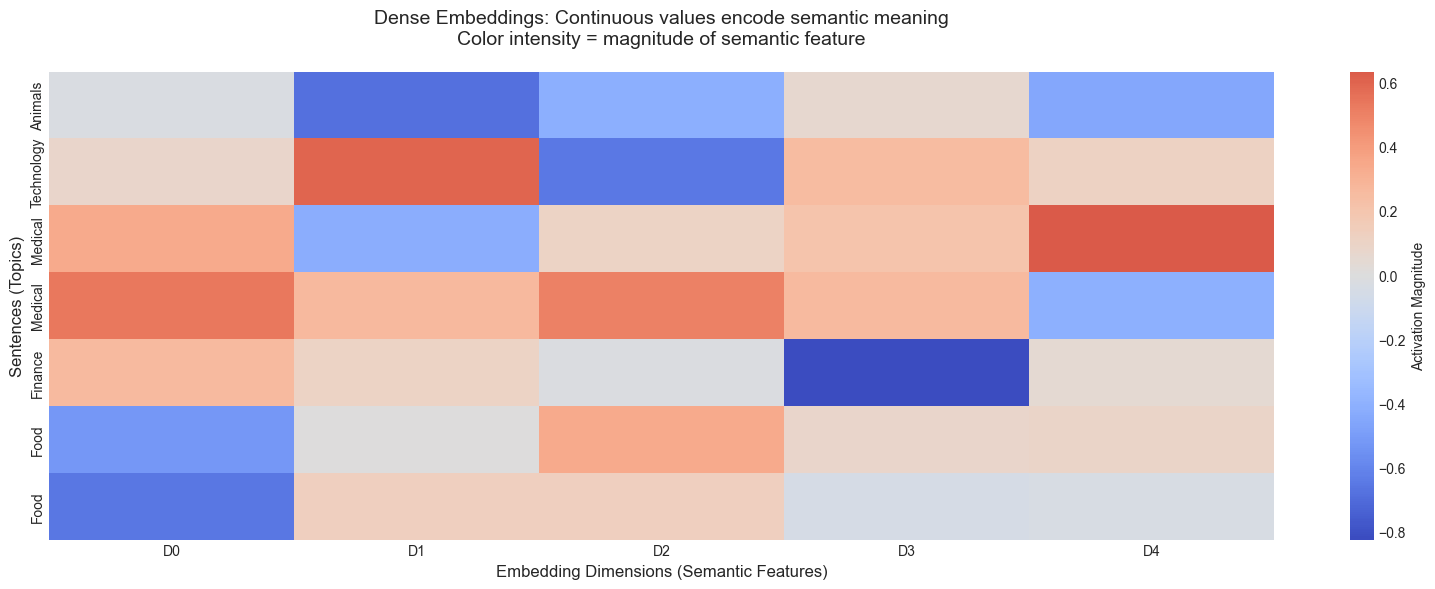


📊 What this shows:
  • Each row = one sentence embedded in 32 dimensions
  • Each column = a semantic feature dimension
  • Color intensity = how much that feature applies
  • Red = high positive value, Blue = high negative value
  • Similar topics may have similar patterns


In [20]:
print("=" * 80)
print("HEATMAP: Embedding Vectors (32 Dimensions)")
print("=" * 80)

# Create comprehensive heatmap
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(embeddings_32d, 
            cmap='coolwarm',
            center=0,
            xticklabels=[f'D{i}' for i in range(len(embeddings_32d[0]))],
            yticklabels=[f"{topic}" for topic in topics],
            cbar_kws={'label': 'Activation Magnitude'},
            ax=ax)

ax.set_xlabel('Embedding Dimensions (Semantic Features)', fontsize=12)
ax.set_ylabel('Sentences (Topics)', fontsize=12)
ax.set_title('Dense Embeddings: Continuous values encode semantic meaning\n' + 
             'Color intensity = magnitude of semantic feature', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

print("\n📊 What this shows:")
print("  • Each row = one sentence embedded in 32 dimensions")
print("  • Each column = a semantic feature dimension")
print("  • Color intensity = how much that feature applies")
print("  • Red = high positive value, Blue = high negative value")
print("  • Similar topics may have similar patterns")

### 4.2 Semantic Similarity Analysis

Now let's see the magic: **similar meanings → similar vectors**

SEMANTIC SIMILARITY MATRIX


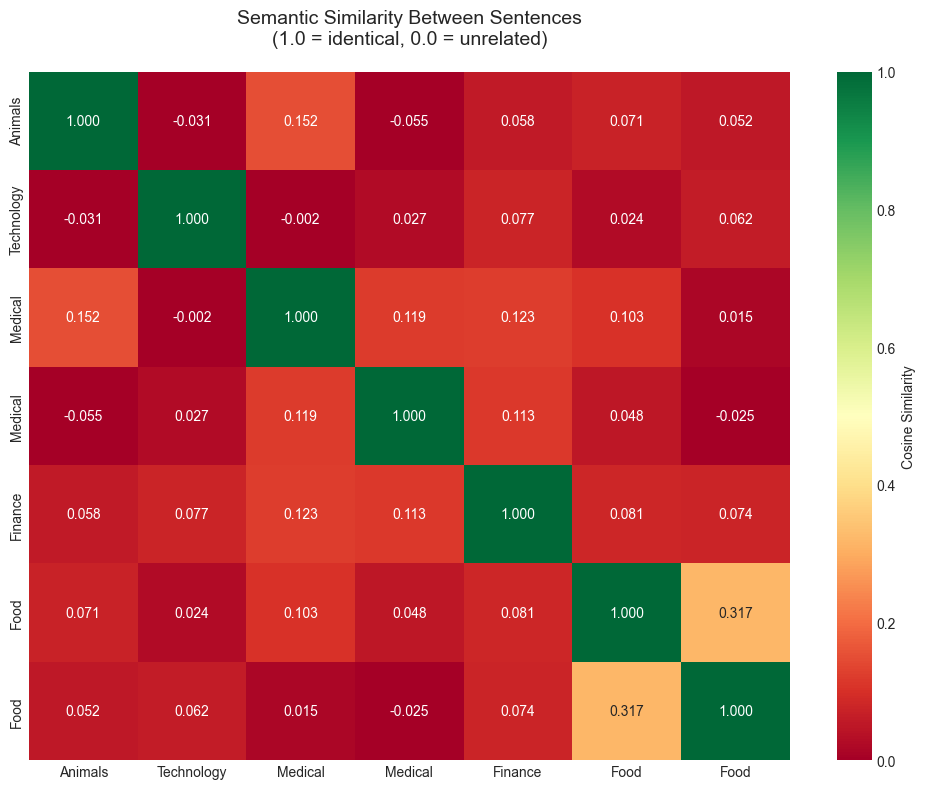


📊 Interpretation:
  • Diagonal = 1.0 (each sentence is identical to itself)
  • Higher values = more semantic similarity
  • Different topics have lower similarity
  • The model captures meaning, not just word overlap!


In [21]:
print("=" * 80)
print("SEMANTIC SIMILARITY MATRIX")
print("=" * 80)

# Calculate cosine similarity between all pairs
similarity_matrix = cosine_similarity(embeddings)

# Visualize similarity matrix
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(similarity_matrix, 
            annot=True, 
            fmt='.3f',
            cmap='RdYlGn',
            xticklabels=topics,
            yticklabels=topics,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Cosine Similarity'},
            ax=ax)

ax.set_title('Semantic Similarity Between Sentences\n' +
             '(1.0 = identical, 0.0 = unrelated)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("  • Diagonal = 1.0 (each sentence is identical to itself)")
print("  • Higher values = more semantic similarity")
print("  • Different topics have lower similarity")
print("  • The model captures meaning, not just word overlap!")

In [27]:
# Demonstrate semantic understanding
print("\n" + "=" * 80)
print("SEMANTIC UNDERSTANDING TEST")
print("=" * 80)

test_sentences = [
    "A dog is playing in the park",  # Similar to Animals
    "Artificial intelligence is changing the world",  # Similar to Technology
    "The nurse checked the vital signs",  # Similar to Medical
]

test_embeddings = st_model.encode(test_sentences)

print("\nTesting semantic similarity:\n")

for test_sent, test_emb in zip(test_sentences, test_embeddings):
    print(f"Query: '{test_sent}'\n")
    
    # Calculate similarity with all original sentences
    similarities = cosine_similarity([test_emb], embeddings)[0]
    
    # Find most similar
    most_similar_idx = np.argmax(similarities)
    
    print("Similarity scores:")
    for i, (topic, score) in enumerate(zip(topics, similarities)):
        marker = " ← MOST SIMILAR" if i == most_similar_idx else ""
        print(f"  {topic:12} {score:.3f} {'█' * int(score * 30)}{marker}")
    print()

print("\n✅ The embeddings understand semantic meaning!")
print("   Similar concepts have high similarity scores.")


SEMANTIC UNDERSTANDING TEST

Testing semantic similarity:

Query: 'A dog is playing in the park'

Similarity scores:
  Animals      0.107 ███ ← MOST SIMILAR
  Technology   0.045 █
  Medical      -0.087 
  Medical      -0.094 
  Finance      -0.025 
  Food         -0.073 
  Food         0.000 

Query: 'Artificial intelligence is changing the world'

Similarity scores:
  Animals      0.010 
  Technology   0.455 █████████████ ← MOST SIMILAR
  Medical      -0.043 
  Medical      -0.019 
  Finance      0.086 ██
  Food         0.056 █
  Food         -0.011 

Query: 'The nurse checked the vital signs'

Similarity scores:
  Animals      0.178 █████
  Technology   0.019 
  Medical      0.483 ██████████████ ← MOST SIMILAR
  Medical      0.225 ██████
  Finance      0.035 █
  Food         0.153 ████
  Food         0.009 


✅ The embeddings understand semantic meaning!
   Similar concepts have high similarity scores.
